In [1]:
import sys
import warnings
import itertools
import calendar
from pylab import rcParams
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv('Sales.xls')

In [3]:
df.head()

,RetailSales
0,2585
1,3368
2,3210
3,3111
4,3756


In [4]:
data = df.copy()

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   RetailSales  187 non-null    int64
dtypes: int64(1)
memory usage: 1.6 KB


In [6]:
dates = pd.date_range(start = '1/1/1997', periods = len(data), freq = 'M')

In [7]:
dates

DatetimeIndex(['1997-01-31', '1997-02-28', '1997-03-31', '1997-04-30',
               '1997-05-31', '1997-06-30', '1997-07-31', '1997-08-31',
               '1997-09-30', '1997-10-31',
               ...
               '2011-10-31', '2011-11-30', '2011-12-31', '2012-01-31',
               '2012-02-29', '2012-03-31', '2012-04-30', '2012-05-31',
               '2012-06-30', '2012-07-31'],
              dtype='datetime64[ns]', length=187, freq='M')

In [8]:
data['Month'] = dates.month
data['Month'] = data['Month'].apply(lambda x: calendar.month_abbr[x])
data['Year'] = dates.year

In [9]:
data.head()

,RetailSales,Month,Year
0,2585,Jan,1997
1,3368,Feb,1997
2,3210,Mar,1997
3,3111,Apr,1997
4,3756,May,1997


In [10]:
data.set_index(dates,inplace=True)

In [11]:
data.head()

,RetailSales,Month,Year
1997-01-31,2585,Jan,1997
1997-02-28,3368,Feb,1997
1997-03-31,3210,Mar,1997
1997-04-30,3111,Apr,1997
1997-05-31,3756,May,1997


In [12]:
sales_ts = data['RetailSales']

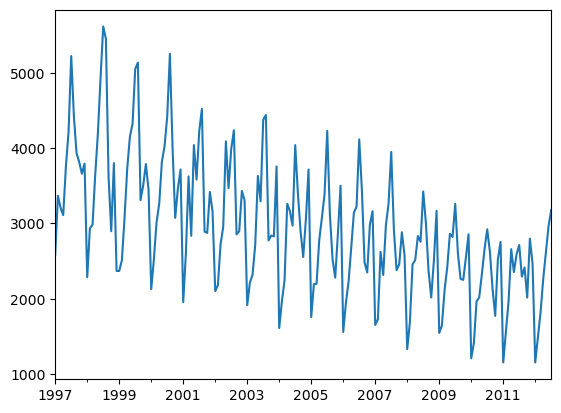

In [76]:
sales_ts.plot()
plt.savefig('data_line_plot.png',bbox_inches='tight')
plt.show();

## Stationarity Test

In [14]:
dftest= adfuller(sales_ts)
dftest[0]

-0.907380399588582

In [15]:
dftest[1]

0.7855322305097701

### Bivariate analysis

In [16]:
monthly_sales = pd.pivot_table(data, values='RetailSales', columns='Year', index='Month')
monthly_sales
monthly_sales = monthly_sales.reindex(index=['Jan', 'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
monthly_sales

Year,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012
Month,,,,,,,,,,,,,,,,
Jan,2585.0,2285.0,2369.0,2127.0,1954.0,2101.0,1914.0,1610.0,1755.0,1558.0,1651.0,1330.0,1545.0,1208.0,1154.0,1153.0
Feb,3368.0,2934.0,2511.0,2523.0,2604.0,2181.0,2214.0,1968.0,2193.0,1940.0,1725.0,1686.0,1643.0,1412.0,1568.0,1482.0
Mar,3210.0,2985.0,3079.0,3017.0,3626.0,2724.0,2320.0,2248.0,2198.0,2226.0,2622.0,2457.0,2112.0,1964.0,1965.0,1818.0
Apr,3111.0,3646.0,3728.0,3265.0,2836.0,2954.0,2714.0,3262.0,2777.0,2676.0,2316.0,2514.0,2415.0,2018.0,2659.0,2262.0
May,3756.0,4198.0,4151.0,3822.0,4042.0,4092.0,3633.0,3164.0,3076.0,3145.0,2976.0,2834.0,2862.0,2329.0,2354.0,2612.0
Jun,4216.0,4935.0,4326.0,4027.0,3584.0,3470.0,3295.0,2972.0,3389.0,3224.0,3263.0,2757.0,2822.0,2660.0,2592.0,2967.0
Jul,5225.0,5618.0,5054.0,4420.0,4225.0,3990.0,4377.0,4041.0,4231.0,4117.0,3951.0,3425.0,3260.0,2923.0,2714.0,3179.0
Aug,4426.0,5454.0,5138.0,5255.0,4523.0,4239.0,4442.0,3402.0,3118.0,3446.0,2917.0,3006.0,2606.0,2626.0,2294.0,NaN
Sep,3932.0,3624.0,3310.0,4009.0,2892.0,2855.0,2774.0,2898.0,2524.0,2482.0,2380.0,2369.0,2264.0,2132.0,2416.0,NaN


In [17]:
yearly_sales = pd.pivot_table(data, values='RetailSales', columns='Month',index='Year')
yearly_sales = yearly_sales[['Jan', 'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]
yearly_sales

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
1997,2585.0,3368.0,3210.0,3111.0,3756.0,4216.0,5225.0,4426.0,3932.0,3816.0,3661.0,3795.0
1998,2285.0,2934.0,2985.0,3646.0,4198.0,4935.0,5618.0,5454.0,3624.0,2898.0,3802.0,2369.0
1999,2369.0,2511.0,3079.0,3728.0,4151.0,4326.0,5054.0,5138.0,3310.0,3508.0,3790.0,3446.0
2000,2127.0,2523.0,3017.0,3265.0,3822.0,4027.0,4420.0,5255.0,4009.0,3074.0,3465.0,3718.0
2001,1954.0,2604.0,3626.0,2836.0,4042.0,3584.0,4225.0,4523.0,2892.0,2876.0,3420.0,3159.0
2002,2101.0,2181.0,2724.0,2954.0,4092.0,3470.0,3990.0,4239.0,2855.0,2897.0,3433.0,3307.0
2003,1914.0,2214.0,2320.0,2714.0,3633.0,3295.0,4377.0,4442.0,2774.0,2840.0,2828.0,3758.0
2004,1610.0,1968.0,2248.0,3262.0,3164.0,2972.0,4041.0,3402.0,2898.0,2555.0,3056.0,3717.0
2005,1755.0,2193.0,2198.0,2777.0,3076.0,3389.0,4231.0,3118.0,2524.0,2280.0,2862.0,3502.0


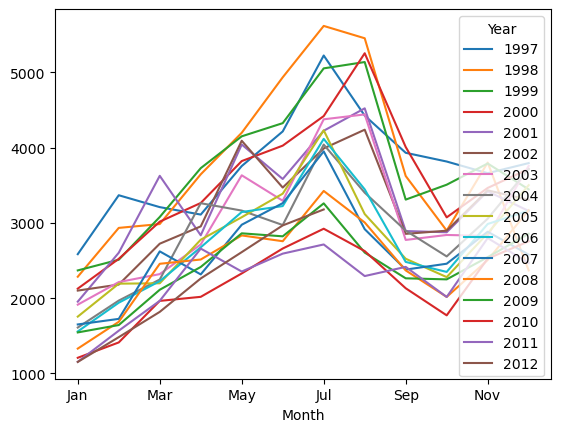

In [77]:
monthly_sales.plot()
plt.savefig('sales_forecast_by_month.png',bbox_inches='tight')
plt.show();

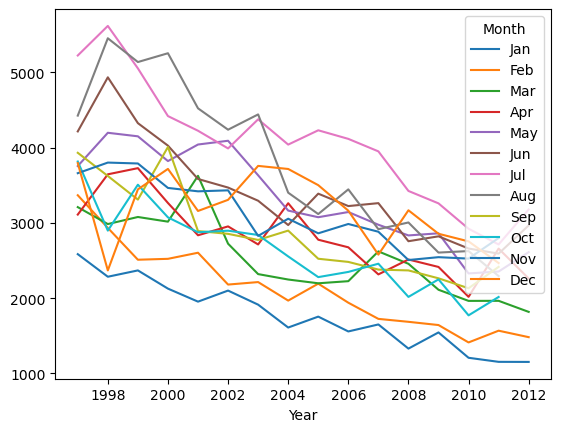

In [19]:
yearly_sales.plot()
plt.show();

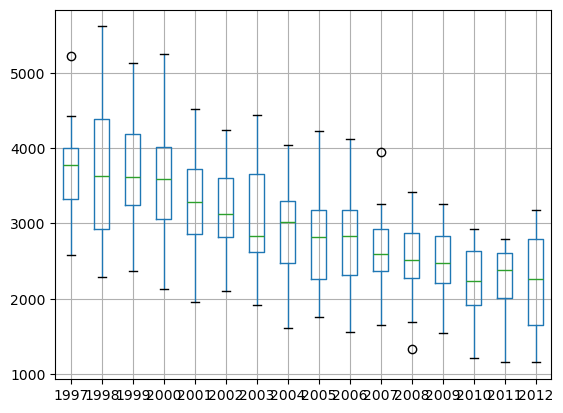

In [20]:
monthly_sales.boxplot()
plt.show();

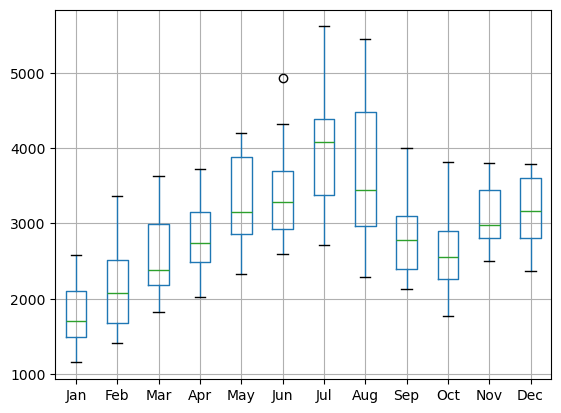

In [21]:
yearly_sales.boxplot()
plt.show();

### Time Series Decomposition

In [22]:
decomposition = sm.tsa.seasonal_decompose(sales_ts, model = 'multiplicative')

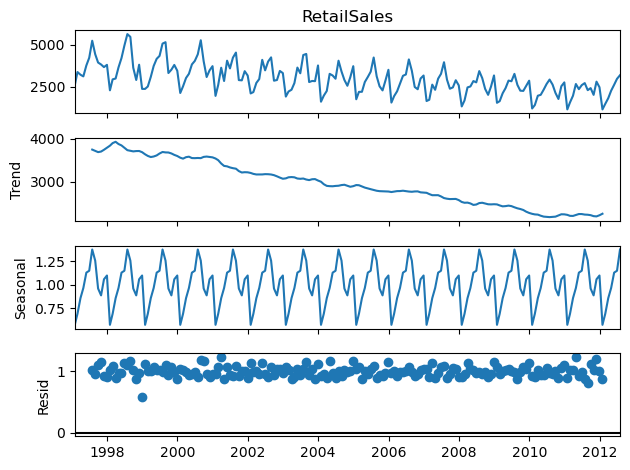

In [23]:
decomposition.plot()
plt.show()

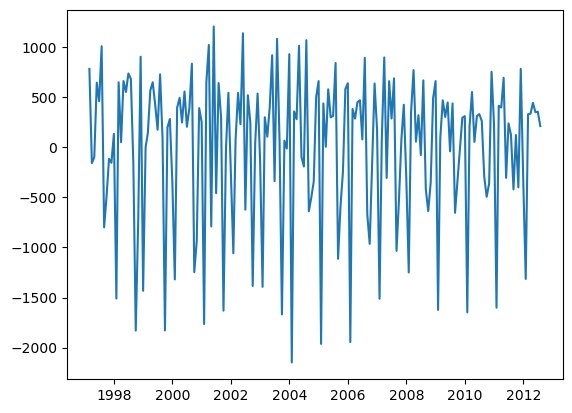

In [24]:
plt.plot(sales_ts.diff(periods=1)) # differencing the data for stationarity
plt.show();

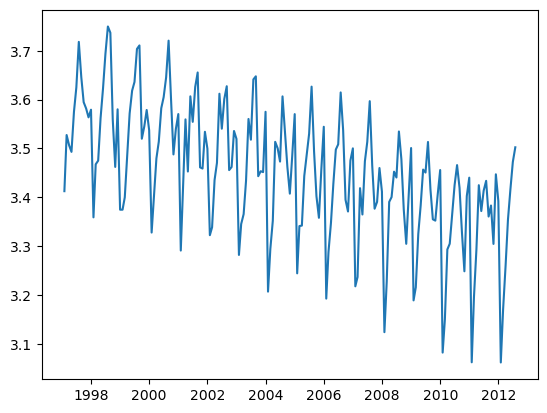

In [25]:
plt.plot(np.log10(sales_ts)) # differencing with log for the variance in the seasonality
plt.show();

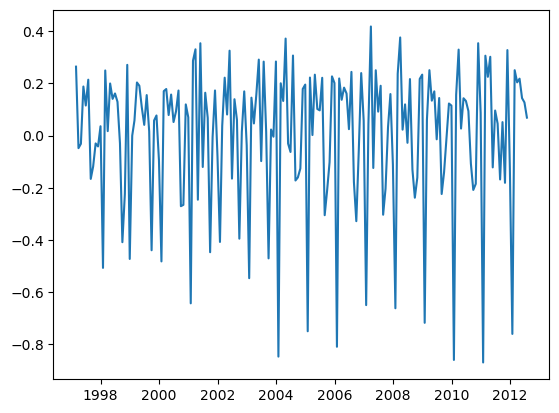

In [26]:
plt.plot(np.log(sales_ts).diff(periods=1)) # combining both the d differencing and log differencing
plt.show();

### Defining (p,d,q) estimation matrix for hyperparamters in model building

In [27]:
p = range(1,4)
d = range(0,2)
q = range(1,4)
pdq_ar = list(itertools.product(p, range(1), range(1)))
pdq_arma = list(itertools.product(p, range(1), q))
pdq_arima = list(itertools.product(p, d, q))
pdq_sarima = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p,d,q))]

In [28]:
pdq_ar

[(1, 0, 0), (2, 0, 0), (3, 0, 0)]

In [29]:
pdq_arma

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3)]

In [30]:
pdq_arima

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3)]

In [31]:
pdq_sarima

[(1, 0, 1, 12),
 (1, 0, 2, 12),
 (1, 0, 3, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 1, 3, 12),
 (2, 0, 1, 12),
 (2, 0, 2, 12),
 (2, 0, 3, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 1, 3, 12),
 (3, 0, 1, 12),
 (3, 0, 2, 12),
 (3, 0, 3, 12),
 (3, 1, 1, 12),
 (3, 1, 2, 12),
 (3, 1, 3, 12)]

### Train test split

In [32]:
train = data[0:int(len(data)*0.7)]
test = data[int(len(data)*0.7):]

In [33]:
dftest = adfuller(sales_ts)
dftest[0]

-0.907380399588582

In [34]:
dftest[1]

0.7855322305097701

### Using log for stationarity for the variance in the data

In [35]:
train_sales_log = np.log10(train['RetailSales'])

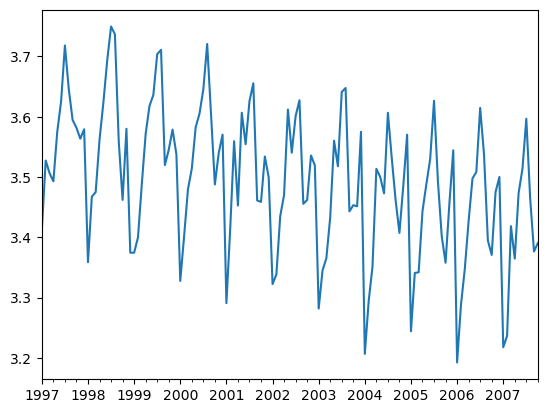

In [36]:
train_sales_log.plot()
plt.show();

### AR Model

In [37]:
ar_aic = pd.DataFrame(columns=['param', 'AIC'])
ar_aic

,param,AIC


In [38]:
for param in pdq_ar:
    ARIMA_model = ARIMA(train_sales_log, order=param).fit()
    ar_aic = pd.concat([
        ar_aic,
        pd.DataFrame({'param':[param], 'AIC':[ARIMA_model.aic]})
    ], ignore_index=True)

In [39]:
ar_aic

,param,AIC
0,"(1, 0, 0)",-228.333911
1,"(2, 0, 0)",-227.040756
2,"(3, 0, 0)",-225.231643


In [40]:
best_results_ar = ARIMA(train_sales_log, order=(1,0,0)).fit()

In [41]:
print(best_results_ar.summary().tables[0])
print(best_results_ar.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:            RetailSales   No. Observations:                  130
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 117.167
Date:                Wed, 30 Apr 2025   AIC                           -228.334
Time:                        20:01:37   BIC                           -219.731
Sample:                    01-31-1997   HQIC                          -224.838
                         - 10-31-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4926      0.026    136.828      0.000       3.443       3.543
ar.L1          0.5492      0.102      5.371      0.000       0.349       0.750
sigma2         0.0096      0.001      8.552      0.0

#### Calculating the RMSE

In [42]:
pred_dynamic_ar = best_results_ar.get_prediction(start=test.index[0], dynamic = True, full_results=True)
pred99_ar = best_results_ar.get_forecast(steps=len(test), alpha=0.1)
sales_ts_forecasted_ar = pred_dynamic_ar.predicted_mean
testcopy_ar = test.copy()
testcopy_ar['sales_ts_forecasted_ar'] = np.power(10, pred99_ar.predicted_mean)

In [43]:
mse_ar = ((testcopy_ar['RetailSales'] - testcopy_ar['sales_ts_forecasted_ar'])**2).mean()
rmse_ar = np.sqrt(mse_ar)
rmse_ar

937.3694770914777

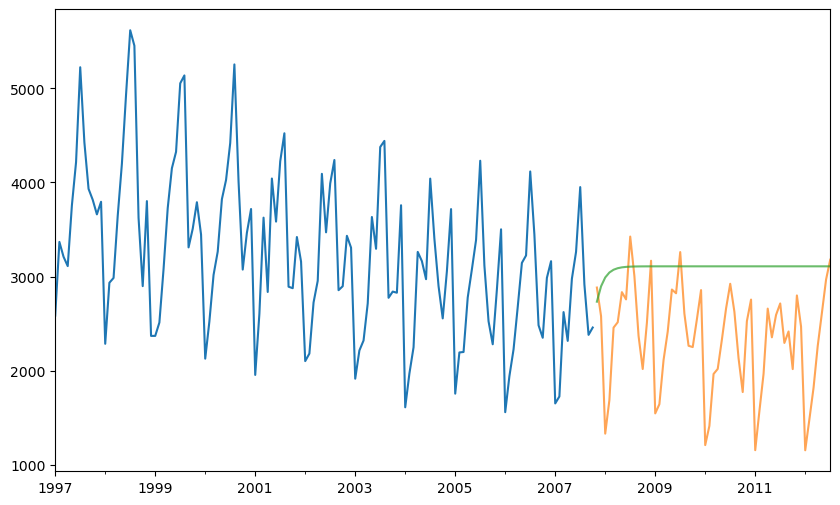

In [44]:
axis = train['RetailSales'].plot(label='Train Sales', figsize=(10,6))
testcopy_ar['RetailSales'].plot(ax=axis, label='Test Sales', alpha=0.7)
testcopy_ar['sales_ts_forecasted_ar'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
plt.show()

In [45]:
resultsdf = pd.DataFrame(columns =['Model','RMSE'])
new_row = pd.DataFrame({'Model':['AR(1,0,0)'],'RMSE':[rmse_ar]})
resultsdf=pd.concat([resultsdf, new_row], ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(1,0,0)",937.369477


### ARMA Model Building

In [46]:
arma_aic = pd.DataFrame(columns=['param','AIC'])
arma_aic

,param,AIC


In [47]:
for param in pdq_arma:
    ARMA_model = ARIMA(train_sales_log, order=param).fit()
    arma_aic = pd.concat([arma_aic,pd.DataFrame({'param':[param],'AIC':[ARMA_model.aic]})], ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [48]:
arma_aic = arma_aic.sort_values(by='AIC', ascending=True)
arma_aic

,param,AIC
7,"(3, 0, 2)",-239.903074
5,"(2, 0, 3)",-231.273856
0,"(1, 0, 1)",-227.175598
3,"(2, 0, 1)",-226.513740
1,"(1, 0, 2)",-225.327197
2,"(1, 0, 3)",-224.822159
6,"(3, 0, 1)",-224.521436
4,"(2, 0, 2)",-224.519935
8,"(3, 0, 3)",-224.199555


In [49]:
best_results_arma = ARIMA(train_sales_log, order=(3,0,2)).fit()
print(best_results_arma.summary().tables[0])
print(best_results_arma.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:            RetailSales   No. Observations:                  130
Model:                 ARIMA(3, 0, 2)   Log Likelihood                 126.952
Date:                Wed, 30 Apr 2025   AIC                           -239.903
Time:                        20:01:40   BIC                           -219.830
Sample:                    01-31-1997   HQIC                          -231.747
                         - 10-31-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5001      0.028    124.732      0.000       3.445       3.555
ar.L1          0.6741      0.089      7.552      0.000       0.499       0.849
ar.L2         -0.8972      0.087    -10.282      0.0

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [50]:
pred_dynamic_arma = best_results_arma.get_prediction(start = test.index[0], dynamic = True, full_results=True)
pred99_arma = best_results_arma.get_forecast(steps=len(test),alpha=0.1)
sales_ts_forecasted_arma = pred_dynamic_arma.predicted_mean
testcopy_arma = test.copy()
testcopy_arma['sales_ts_forecasted_arma'] = np.power(10, pred99_arma.predicted_mean)

In [51]:
mse_arma = ((testcopy_arma['RetailSales'] - testcopy_arma['sales_ts_forecasted_arma'])**2).mean()
rmse_arma = np.sqrt(mse_arma)
rmse_arma

960.917067161

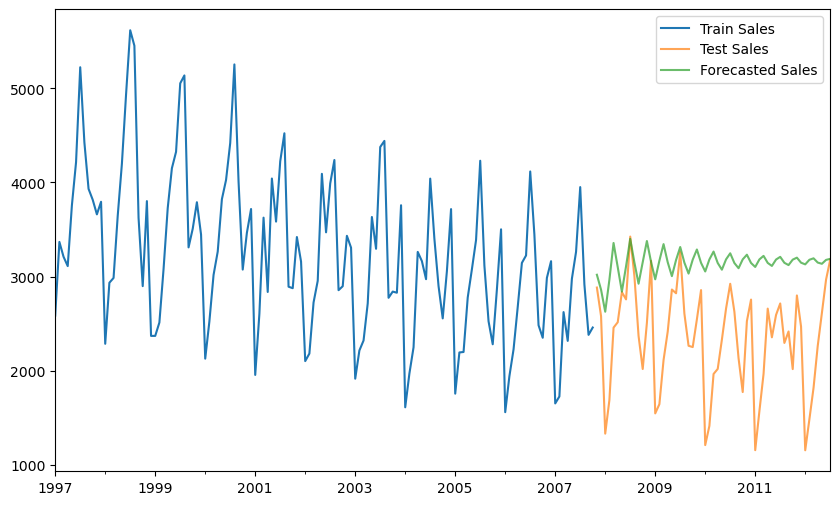

In [52]:
axis = train['RetailSales'].plot(label='Train Sales', figsize=(10,6))
test['RetailSales'].plot(ax= axis, label='Test Sales', alpha=0.7)
testcopy_arma['sales_ts_forecasted_arma'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
plt.legend()
plt.show();

In [53]:
pdresults_arma = pd.DataFrame({'Model':['ARMA(3,0,2)'],'RMSE':[rmse_arma]})
resultsdf = pd.concat([resultsdf, pdresults_arma], ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(1,0,0)",937.369477
1,"ARMA(3,0,2)",960.917067


### ARIMA Model

In [54]:
arima_aic = pd.DataFrame(columns=['param','AIC'])
arima_aic

,param,AIC


In [55]:
for param in pdq_arima:
    ARIMA_model1 = ARIMA(train_sales_log, order=param).fit()
    arima_aic = pd.concat([arima_aic, pd.DataFrame({'param':[param], 'AIC':[ARIMA_model1.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [56]:
arima_aic = arima_aic.sort_values(by='AIC')
arima_aic

,param,AIC
17,"(3, 1, 3)",-243.771933
13,"(3, 0, 2)",-239.903074
10,"(2, 1, 2)",-232.622187
8,"(2, 0, 3)",-231.273856
0,"(1, 0, 1)",-227.175598
6,"(2, 0, 1)",-226.513740
16,"(3, 1, 2)",-226.370951
1,"(1, 0, 2)",-225.327197
3,"(1, 1, 1)",-225.034852
2,"(1, 0, 3)",-224.822159


In [57]:
best_results_arima = ARIMA(train_sales_log,order=(3,1,3)).fit()

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [58]:
print(best_results_arima.summary().tables[0])
print(best_results_arima.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:            RetailSales   No. Observations:                  130
Model:                 ARIMA(3, 1, 3)   Log Likelihood                 128.886
Date:                Wed, 30 Apr 2025   AIC                           -243.772
Time:                        20:01:44   BIC                           -223.753
Sample:                    01-31-1997   HQIC                          -235.638
                         - 10-31-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7651      0.112      6.805      0.000       0.545       0.986
ar.L2         -0.9976      0.031    -32.697      0.000      -1.057      -0.938
ar.L3          0.7431      0.109      6.815      0.0

In [60]:
pred_dynamic_arima = best_results_arima.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred99_arima = best_results_arima.get_forecast(steps=len(test), alpha=0.1)
sales_ts_forecasted_arima = pred_dynamic_arima.predicted_mean
testcopy_arima = test.copy()
testcopy_arima['sales_ts_forecasted_arima']=np.power(10, pred99_arima.predicted_mean)

In [61]:
mse_arima = ((testcopy_arima['RetailSales'] - testcopy_arima['sales_ts_forecasted_arima'])**2).mean()
rmse_arima = np.sqrt(mse_arima)
rmse_arima

897.7150814661903

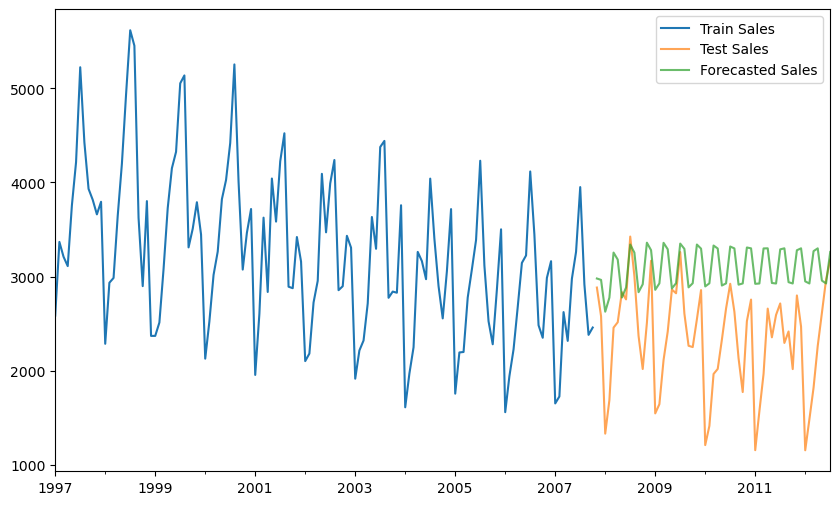

In [62]:
axis = train['RetailSales'].plot(label='Train Sales', figsize=(10,6))
testcopy_arima['RetailSales'].plot(ax= axis, label='Test Sales',alpha=0.7)
testcopy_arima['sales_ts_forecasted_arima'].plot(ax=axis,label='Forecasted Sales', alpha=0.7)
plt.legend()
plt.show();

In [63]:
results_arima = pd.DataFrame({'Model':['ARIMA(3,1,3)'],'RMSE':[rmse_arima]})
resultsdf = pd.concat([resultsdf, results_arima], ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(1,0,0)",937.369477
1,"ARMA(3,0,2)",960.917067
2,"ARIMA(3,1,3)",897.715081


### SARIMA Model

In [64]:
sarima_aic = pd.DataFrame(columns=['param','seasonal','AIC'])
sarima_aic

,param,seasonal,AIC


In [65]:
for param in pdq_arima:
    for seasonal_param in pdq_sarima:
        SARIMA_model = sm.tsa.statespace.SARIMAX(train_sales_log,
                                                order=param, #pdq parameters for estimation
                                                seasonal_order=seasonal_param, #seasonal parameters for estimation
                                                enforce_stationarity=False, #allows model to fit even for non-stationary data
                                                enforce_invertibility=False).fit(maxiter=1000) #allows intertible moving average models
        sarima_aic = pd.concat([sarima_aic, pd.DataFrame({'param':[param],'seasonal':[seasonal_param],'AIC':[SARIMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [66]:
sarima_aic = sarima_aic.sort_values(by='AIC')
sarima_aic

,param,seasonal,AIC
234,"(3, 0, 2)","(1, 0, 1, 12)",-377.176223
0,"(1, 0, 1)","(1, 0, 1, 12)",-376.052923
216,"(3, 0, 1)","(1, 0, 1, 12)",-375.820028
36,"(1, 0, 3)","(1, 0, 1, 12)",-375.428845
18,"(1, 0, 2)","(1, 0, 1, 12)",-374.973196
...,...,...,...
56,"(1, 1, 1)","(1, 0, 3, 12)",3830.165595
62,"(1, 1, 1)","(2, 0, 3, 12)",3851.892348
122,"(2, 0, 1)","(3, 0, 3, 12)",4622.687939
308,"(3, 1, 3)","(1, 0, 3, 12)",5045.398142


In [67]:
best_results_sarima = sm.tsa.statespace.SARIMAX(train_sales_log, order=(3,0,2), seasonal_order =(1,0,1,12), enforce_stationarity=True).fit()
print(best_results_sarima.summary().tables[0])
print(best_results_sarima.summary().tables[1])

                                      SARIMAX Results                                       
Dep. Variable:                          RetailSales   No. Observations:                  130
Model:             SARIMAX(3, 0, 2)x(1, 0, [1], 12)   Log Likelihood                 197.580
Date:                              Wed, 30 Apr 2025   AIC                           -379.159
Time:                                      20:16:05   BIC                           -356.219
Sample:                                  01-31-1997   HQIC                          -369.838
                                       - 10-31-2007                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7180      0.978      0.734      0.463      -1.198       2.634
ar.L2          0.35

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [68]:
pred_dynamic_sarima = best_results_sarima.get_prediction(start=test.index[0],dynamic=True,full_results=True)
pred99_sarima = best_results_sarima.get_forecast(steps=len(test),alpha=0.01)
sales_ts_forecasted_sarima = pred_dynamic_sarima.predicted_mean
testcopy_sarima = test.copy()
testcopy_sarima['sales_ts_forecasted_sarima'] = np.power(10, pred99_sarima.predicted_mean)

In [69]:
mse_sarima = ((testcopy_sarima['RetailSales'] - testcopy_sarima['sales_ts_forecasted_sarima'])**2).mean()
rmse_sarima = np.sqrt(mse_sarima)
rmse_sarima

236.52135756082205

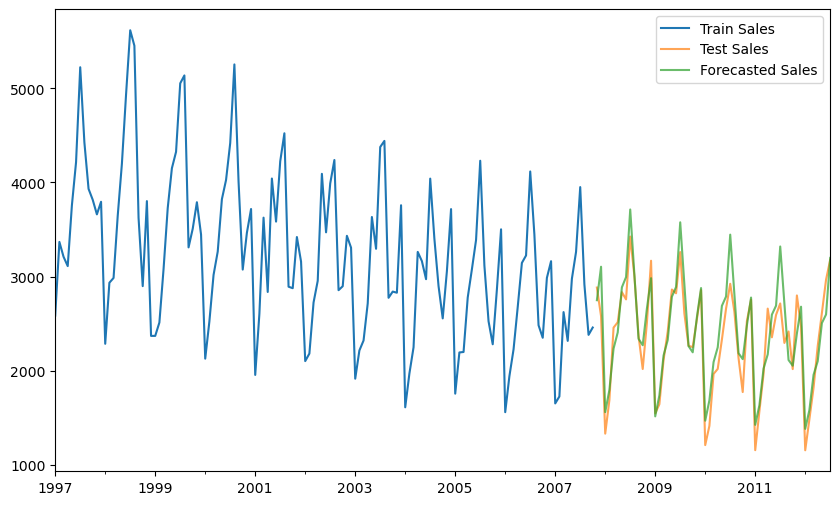

In [70]:
axis = train['RetailSales'].plot(label='Train Sales', figsize = (10,6))
testcopy_sarima['RetailSales'].plot(ax = axis, label='Test Sales', alpha=0.7)
testcopy_sarima['sales_ts_forecasted_sarima'].plot(ax=axis, label='Forecasted Sales',alpha=0.7)
plt.legend()
plt.show()

In [71]:
results_sarima = pd.DataFrame({'Model':['SARIMA(3,0,2)(1,0,1,12)'],'RMSE':[rmse_sarima]})
resultsdf = pd.concat([resultsdf, results_sarima], ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(1,0,0)",937.369477
1,"ARMA(3,0,2)",960.917067
2,"ARIMA(3,1,3)",897.715081
3,"SARIMA(3,0,2)(1,0,1,12)",236.521358


## Best Model Fit - SARIMA

In [72]:
n_steps = 36
pred_uc_99 = best_results_sarima.get_forecast(steps = 36, alpha = 0.01)
pred_uc_95 = best_results_sarima.get_forecast(steps = 36, alpha = 0.05)
pred_ci_99 = pred_uc_99.conf_int()
pred_ci_95 = pred_uc_95.conf_int()

In [73]:
n_steps = 36
idx = pd.date_range(start = '2012-08-01', periods=36, freq='MS')
fc_95 = pd.DataFrame(np.column_stack([np.power(10, pred_uc_95.predicted_mean),np.power(10, pred_ci_95)]),
                     index=idx, columns = ['forecast','lower_ci_95','upper_ci_95'])
fc_99 = pd.DataFrame(np.column_stack([np.power(10,pred_ci_99)]), index=idx, columns=['lower_ci_99','upper_ci_99'])
fc = fc_95.combine_first(fc_99)
fc = fc[['forecast','lower_ci_95','upper_ci_95','lower_ci_99','upper_ci_99']]
fc.head()

,forecast,lower_ci_95,upper_ci_95,lower_ci_99,upper_ci_99
2012-08-01,2748.473711,2242.796288,3368.164903,2242.796288,3368.164903
2012-09-01,3104.274935,2533.137932,3804.184032,2533.137932,3804.184032
2012-10-01,1558.543454,1269.505665,1913.388623,1269.505665,1913.388623
2012-11-01,1794.905521,1461.976235,2203.651298,1461.976235,2203.651298
2012-12-01,2234.049356,1818.962732,2743.858594,1818.962732,2743.858594


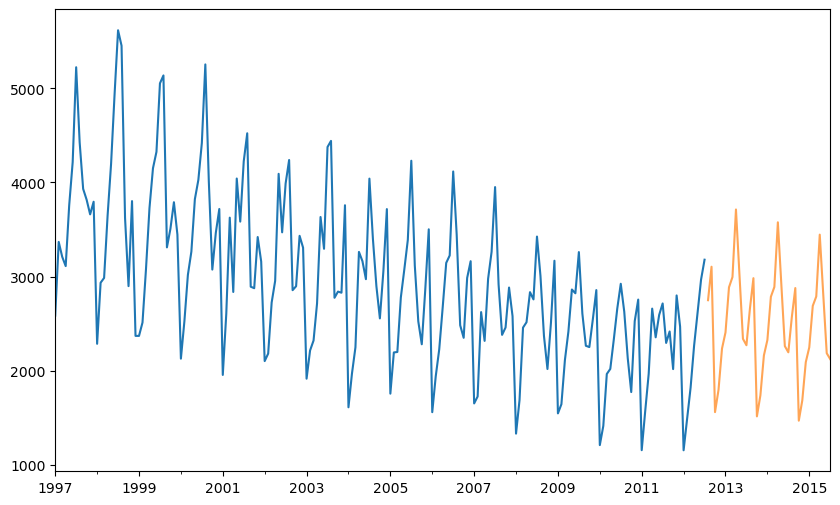

In [74]:
axis = sales_ts.plot(figsize=(10,6))
fc['forecast'].plot(ax= axis, alpha=0.7)
plt.show();

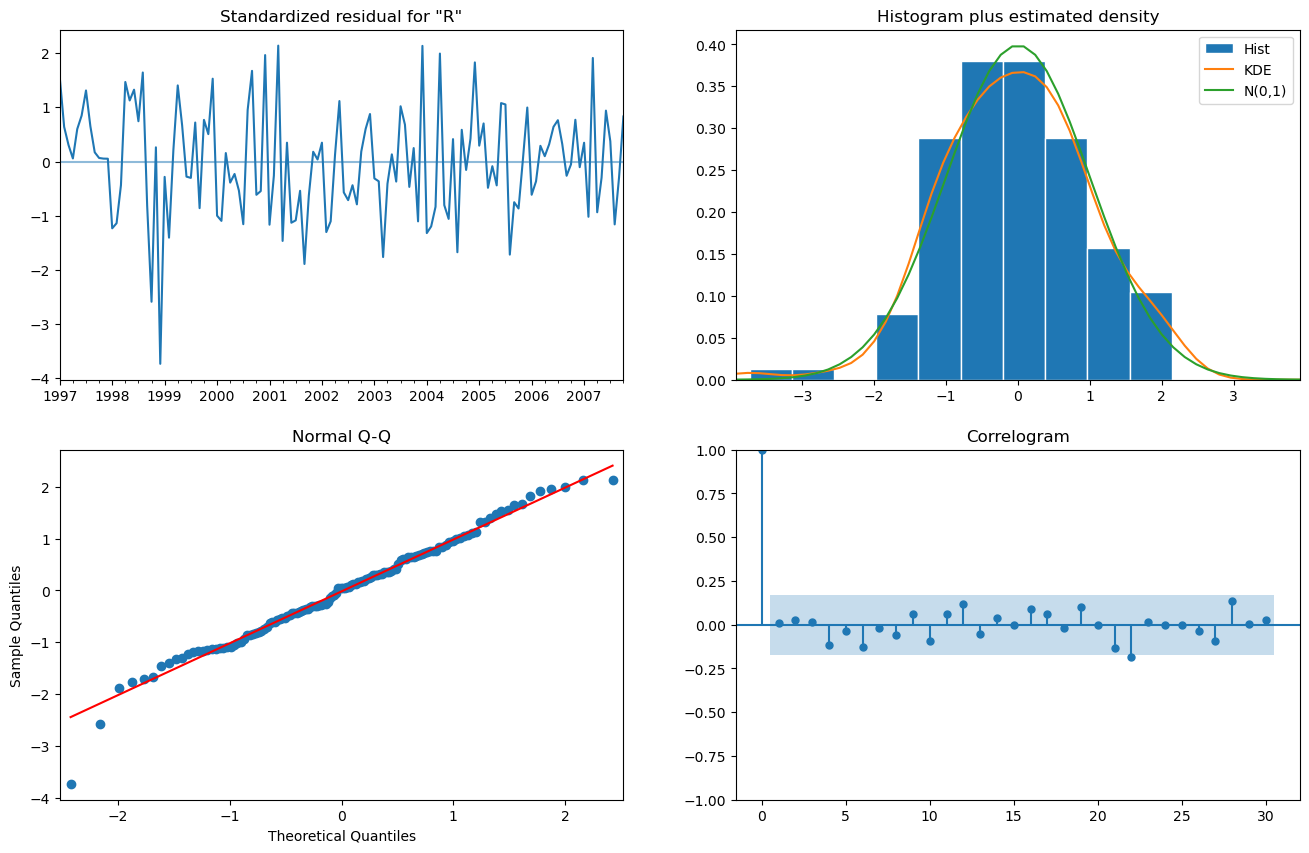

In [75]:
best_results_sarima.plot_diagnostics(lags=30, figsize=(16,10))
plt.savefig('plotdiagnostics.png')
plt.show();